In [1]:
import os
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
import sys
import numpy as np
from thesis_ml.xy_vae import VAE
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import sklearn.cluster as skl_cluster
from sklearn import manifold, decomposition, datasets
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from sklearn.cluster import SpectralClustering
import statistics
import matplotlib.patches as mpatches
import glob
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm 

2025-08-14 14:34:50.370036: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-14 14:34:50.398460: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755196490.415124 2274617 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755196490.420154 2274617 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755196490.433533 2274617 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

0.08816, 0.150677, 0.211249, 0.269835, 0.326389, 0.38086, 0.433194, 0.483332, 0.531206, 0.576744, 0.619862, 0.660467, 0.698449, 0.733681, 0.766013, 0.795259, 0.821183, 0.843471, 0.86167, 0.875025, 0.8816, 0.889763, 0.897926, 0.906089, 0.914252, 0.922415, 0.930578, 0.938741, 0.946904, 0.955067, 0.96323, 0.971393, 0.979556, 0.987719, 0.995881, 1.004044, 1.012207, 1.02037, 1.028533, 1.036696, 1.044859, 1.053022, 1.061185, 1.069348, 1.077511, 1.085674, 1.093837, 1.102, 1.102, 1.10967, 1.125252, 1.146484, 1.172487, 1.202731, 1.236851, 1.274572, 1.315677, 1.359989, 1.407361, 1.457665, 1.510792, 1.566646, 1.62514, 1.686196, 1.749746, 1.815725, 1.884076, 1.954744


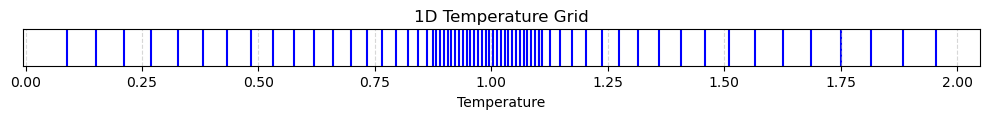

In [28]:
# Temp grid maker
Tc = 0.8816
zoom_start = 1.0* Tc 
zoom_end = 1.25 * Tc
cold_end = 0.1 * Tc   # Minimum temperature
hot_end = 2.3 * Tc    # Maximum temperature
total_points = 70     # Total number of points
zoom_fraction = 0.4   # Fraction of points in zoom region

# ----- Computation -----
# Define zoom region

# Points in zoom vs outside
n_zoom = int(total_points * zoom_fraction)
n_outer = total_points - n_zoom
def smooth_space(start, end, num, power=2.0, cluster_at='end'):

    x = np.linspace(0, 1, num)
    
    if cluster_at == 'start':
        weights = x**power            # Cluster near start
    elif cluster_at == 'end':
        weights = 1 - (1 - x)**power  # Cluster near end
    else:
        raise ValueError("cluster_at must be 'start' or 'end'")
        
    return start + (end - start) * weights



cold_part = smooth_space(cold_end, zoom_start, n_outer // 2, power=1.6, cluster_at='end')[:-1]

hot_part = smooth_space(zoom_end, hot_end, n_outer // 2, power=1.6, cluster_at='start')[:-1]

# Zoom region (dense sampling)
zoom_part = np.linspace(zoom_start, zoom_end, n_zoom)

# Combine
temps = np.concatenate([cold_part, zoom_part, hot_part])
temps = np.round(temps, 6)
temps.sort()

# Output comma-separated
comma_separated = ', '.join(map(str, temps))
print(comma_separated)

plt.figure(figsize=(10, 1.3))
plt.scatter(temps, np.zeros_like(temps), marker='|', color='blue', s=5000)
plt.title('1D Temperature Grid')
plt.yticks([])
plt.xlabel('Temperature')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [54]:
#temps good 16x16
temps = np.array([0.500000, 0.525510, 0.551020, 0.576531, 0.602041, 0.627551, 0.653061, 0.678571, 0.704082, 0.729592, 
                    0.755102, 0.780612, 0.806122, 0.831633, 0.857143, 0.882653, 0.908163, 0.933673, 0.959184, 0.984694, 
                    1.010204, 1.035714, 1.061224, 1.086735, 1.112245, 1.137755, 1.163265, 1.188776, 1.214286, 1.239796, 
                    1.265306, 1.290816, 1.316327, 1.341837, 1.367347, 1.392857, 1.418367, 1.443878, 1.469388, 1.494898, 
                    1.520408, 1.545918, 1.571429, 1.596939, 1.622449, 1.647959, 1.673469, 1.698980, 1.724490, 1.750000
                 ])

In [2]:
#temps good 32x32
temps = np.array([0.500000, 0.525510, 0.551020, 0.576531, 0.602041, 0.627551, 0.653061, 0.678571, 0.704082, 0.729592,
                 0.755102, 0.780612, 0.806122, 0.831633, 0.857143, 0.881600, 0.892055, 0.902510, 0.912966, 0.923421, 
                 0.933876, 0.944331, 0.954786, 0.965241, 0.975697, 0.986152, 0.996607, 1.007062, 1.017517, 1.027972, 
                 1.038428, 1.048883, 1.059338, 1.069793, 1.080248, 1.090703, 1.101159, 1.111614, 1.122069, 1.132524, 
                 1.142979, 1.153434, 1.163890, 1.174345, 1.184800, 1.190160, 1.214286, 1.239796, 1.265306, 1.290816, 
                 1.316327, 1.341837, 1.367347, 1.392857, 1.418367, 1.443878, 1.469388, 1.494898, 1.520408, 1.545918,
                 1.571429, 1.596939, 1.622449, 1.647959, 1.673469, 1.698980, 1.724490, 1.750000
                 ])
print(temps.size)

NameError: name 'np' is not defined

In [55]:
# --- Parameters ---
L = 64
N = L * L
Tc = 0.892

temps = np.round(temps, 6)  # Avoid float comparison issues
temps_scaled = temps / Tc

data_dir = "testXY64.2"
file_list = sorted(
    f for f in os.listdir(data_dir)
    if os.path.isfile(os.path.join(data_dir, f))
)[:1000000000]  # limit max files

# --- Containers ---
magnetizations = []
temp_labels = []
avg_cos = []
avg_sin = []
X_vals = []
Y_vals = []
T_vals = []

# --- Load & process ---
for file_name in tqdm(file_list, desc="Loading files", unit="file"):
    with open(os.path.join(data_dir, file_name), 'r') as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        theta = np.fromstring(line, sep=' ')
        if theta.size != N:
            continue

        T = temps[i % len(temps)]
        cos_theta = np.cos(theta)
        sin_theta = np.sin(theta)

        # Magnetization
        M = np.abs(np.sum(np.exp(1j * theta))) / N
        magnetizations.append(M)
        temp_labels.append(T)

        X_vals.extend(cos_theta)
        Y_vals.extend(sin_theta)
        T_vals.extend([T / Tc] * N)

        avg_cos.append(np.mean(cos_theta))
        avg_sin.append(np.mean(sin_theta))

# --- Convert to arrays ---
magnetizations = np.array(magnetizations, dtype=np.float32)
temp_labels = np.array(temp_labels, dtype=np.float32)
temp_labels_scaled = temp_labels / Tc
X_vals = np.array(X_vals, dtype=np.float32)
Y_vals = np.array(Y_vals, dtype=np.float32)
T_vals = np.array(T_vals, dtype=np.float32)
avg_cos = np.array(avg_cos, dtype=np.float32)
avg_sin = np.array(avg_sin, dtype=np.float32)


Loading files:   0%|          | 0/500 [00:00<?, ?file/s]

In [56]:
print(temp_labels.shape)

(25000,)


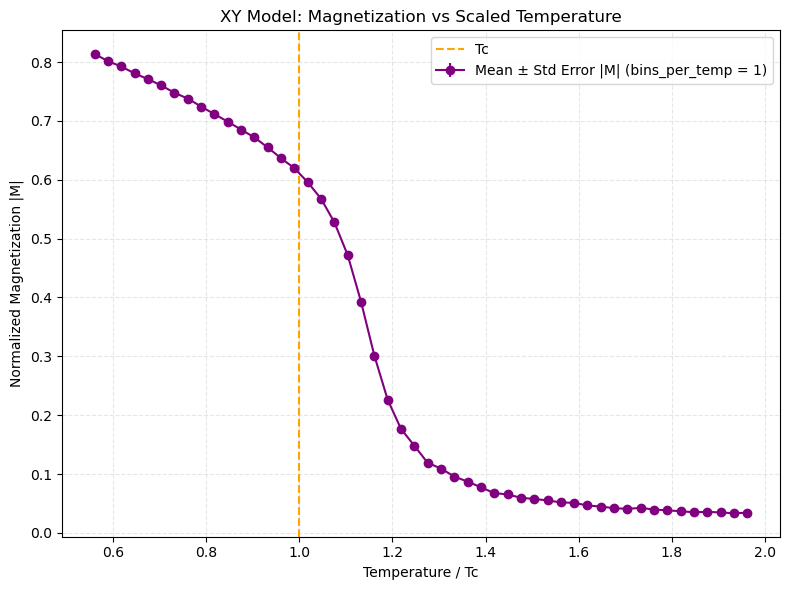

Saved curve data to 'binned_magnetization_curve_goodXY16.1.csv'


In [57]:
# --- Bin data per temperature ---
bins_per_temp = 1
unique_temps = np.unique(temp_labels)
bin_means = []
bin_stds = []
bin_counts = []
bin_centers = []

for T in unique_temps:
    mask = temp_labels == T
    indices = np.where(mask)[0]
    np.random.shuffle(indices)
    
    sub_bins = np.array_split(indices, bins_per_temp)
    for sub in sub_bins:
        if len(sub) > 0:
            m_vals = magnetizations[sub]
            bin_means.append(np.mean(m_vals))
            bin_stds.append(np.std(m_vals))
            bin_counts.append(len(m_vals))
            bin_centers.append(T / Tc)

# --- Sort and compute error ---
bin_centers = np.array(bin_centers)
bin_means = np.array(bin_means)
bin_stds = np.array(bin_stds)
bin_counts = np.array(bin_counts)
bin_stderr = bin_stds / np.sqrt(bin_counts)

sort_idx = np.argsort(bin_centers)
bin_centers = bin_centers[sort_idx]
bin_means = bin_means[sort_idx]
bin_stderr = bin_stderr[sort_idx]

# --- Plot ---
plt.figure(figsize=(8, 6))
plt.errorbar(bin_centers, bin_means, yerr=bin_stderr, fmt='-o', color='purple',
             label=f'Mean ± Std Error |M| (bins_per_temp = {bins_per_temp})')
# plt.plot(fit_x, fit_y, 'r--', label=f'Sigmoid Fit (a={popt[0]:.2f}, b={popt[1]:.2f})')

plt.axvline(1.0, color='orange', linestyle='--', label='Tc')
plt.xlabel("Temperature / Tc")
plt.ylabel("Normalized Magnetization |M|")
plt.title("XY Model: Magnetization vs Scaled Temperature")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- Save processed curve using np.savetxt ---
output_filename = "binned_magnetization_curve_goodXY16.1.csv"
curve_data = np.column_stack((bin_centers, bin_means, bin_stderr))
header = "Temperature_Tc,Mean_Magnetization,Standard_Error"

np.savetxt(output_filename, curve_data, delimiter=",", header=header, comments='')
print(f"Saved curve data to '{output_filename}'")


In [13]:
# Repeat magnetization magnitude so each spin has its config's |M|
M_vals = np.repeat(magnetizations, N)

# Scale the unit vectors (cosθ, sinθ) by magnetization magnitude
X_plot = M_vals * X_vals  # M * cosθ
Y_plot = M_vals * Y_vals  # M * sinθ

plt.figure(figsize=(6, 6))
sc = plt.scatter(X_plot, Y_plot, c=T_vals, cmap='viridis', s=.1, alpha=0.6)
cbar = plt.colorbar(sc, label='Temperature / Tc')
plt.title("XY Model Spin Directions\nDistance from Origin = |Magnetization|")
plt.xlabel("x = |M| · cos(θ)")
plt.ylabel("y = |M| · sin(θ)")
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

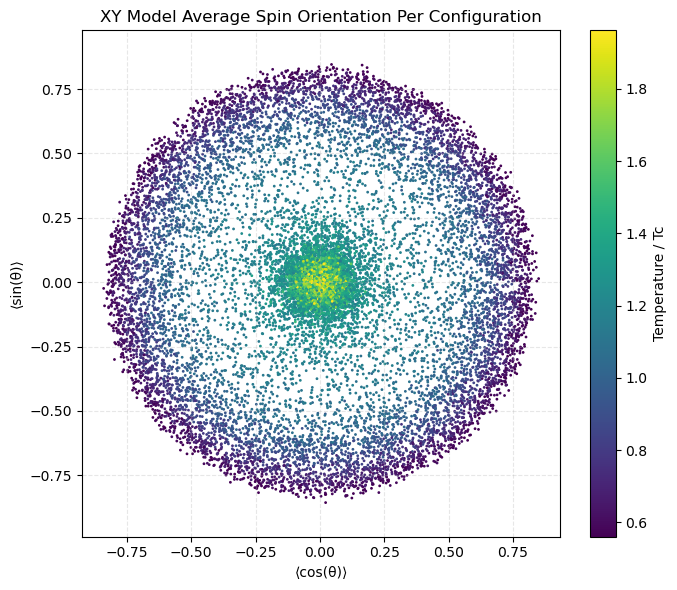

In [58]:
avg_cos = np.array(avg_cos)
avg_sin = np.array(avg_sin)
avg_temp = np.array(temp_labels_scaled)  # already defined in your loading script

# --- Scatter plot of average orientations ---|
plt.figure(figsize=(7, 6))
sc = plt.scatter(avg_cos, avg_sin, c=avg_temp, cmap='viridis', s=1)
cbar = plt.colorbar(sc, label='Temperature / Tc')
plt.title("XY Model Average Spin Orientation Per Configuration")
plt.xlabel("⟨cos(θ)⟩")
plt.ylabel("⟨sin(θ)⟩")
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [59]:
X_vals = np.array(X_vals)
Y_vals = np.array(Y_vals)

# Combine and reshape
data_vec = np.stack([X_vals, Y_vals], axis=-1)  # shape: (total_spins, 2)
data_xy = data_vec.reshape((-1, L, L, 2))       # shape: (num_configs, L, L, 2)

In [60]:
# Split into train/test
split = int(len(data_xy) * 0.8)
train_data = data_xy[:split]
test_data = data_xy[split:]

vae = VAE(
    train_images=train_data,
    test_images=test_data,
    batch_size=48,
    epochs=45,
    latent_dim=2  # must be 2 for 2D latent space visualization
)
vae.saveModel("XYtest64.1.keras")



Epoch: 45, Test set ELBO: -5239.3228, time elapse for current epoch: 2.06s


/home/lledson/.conda/envs/myenv/lib/python3.10/site-packages/keras/src/saving/saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)


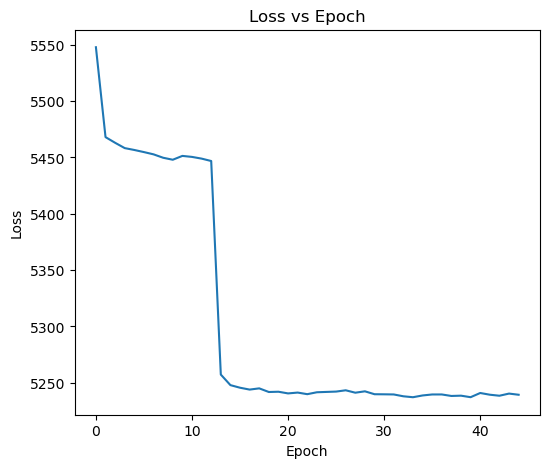

In [61]:
vae.plot_loss()

In [37]:
model_path = "XYtest32.1.keras"
vae = VAE(load=model_path)

/home/lledson/.conda/envs/myenv/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


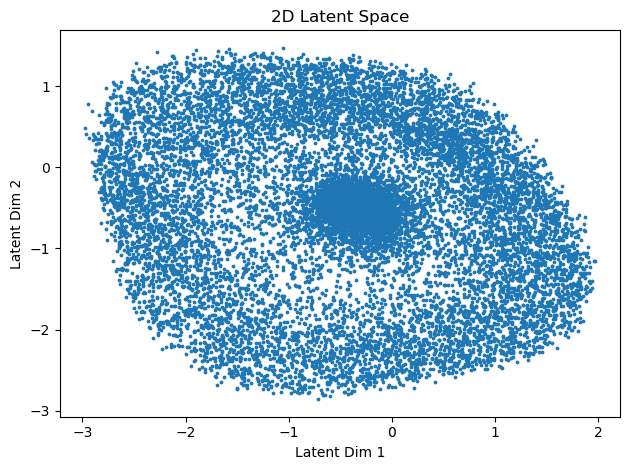

In [62]:
# Encode test data to get means and logvars
batch_size = 128
means_list = []
logvars_list = []

for i in range(0, len(data_xy), batch_size):
    batch = data_xy[i:i + batch_size]
    m, l = vae.encode(batch, both=True)
    means_list.append(m.numpy())     # Convert from tensor to numpy
    logvars_list.append(l.numpy())   # Same here

means = np.concatenate(means_list, axis=0)
logvars = np.concatenate(logvars_list, axis=0)

# np.save("latent_means_test256.1.npy", means)
# np.save("latent_logvars_test256.1.npy", logvars)

# Plot the 2D latent space
plt.scatter(means[:, 0], means[:, 1], s=3)
plt.title("2D Latent Space")
plt.xlabel("Latent Dim 1")
plt.ylabel("Latent Dim 2")
plt.tight_layout()
# plt.savefig("latent_space_test256.1.png", dpi=300)
plt.show()

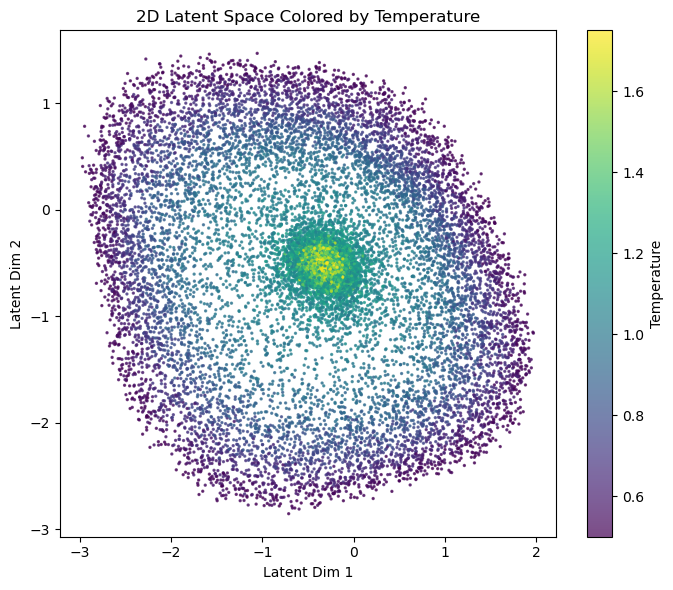

In [63]:
# train_temps = temp_labels[:split]
# test_temps = temp_labels[split:]


plt.figure(figsize=(7, 6))
sc = plt.scatter(means[:, 0], means[:, 1], c=temp_labels, cmap='viridis', s=2, alpha =.7)
plt.colorbar(sc, label='Temperature')
plt.title("2D Latent Space Colored by Temperature")
plt.xlabel("Latent Dim 1")
plt.ylabel("Latent Dim 2")
plt.tight_layout()
plt.show()

In [71]:
# ----------- Configuration -----------
data_dir = "testXY64.1"
output_dir = "overlap_batches_testXY64.1"
os.makedirs(output_dir, exist_ok=True)

def compute_overlap_matrix(mu, sigma):
    mu_i = mu[:, None]
    mu_j = mu[None, :]
    sigma_i = sigma[:, None]
    sigma_j = sigma[None, :]
    
    sigma_sq_sum = sigma_i ** 2 + sigma_j ** 2
    coef = (2 * sigma_i * sigma_j) / sigma_sq_sum
    exponent = -((mu_i - mu_j) ** 2) / (4 * sigma_sq_sum)
    return (coef * np.exp(exponent)).astype(np.float32)


alpha = .7

fitImgsVAE = means.astype(np.float32)
fitImgsSTD = alpha * np.exp(logvars) ** 0.5
fitImgsSTD = fitImgsSTD.astype(np.float32)

file_list = ([f for f in os.listdir(data_dir)
                    if os.path.isfile(os.path.join(data_dir, f))])
MAX_SEEDS = 10000000
file_list = file_list[:MAX_SEEDS]

samples_per_seed = 50  # Assuming 50 temperatures per seed
seeds_per_batch = 100  # So 125 * 40 = 5000 samples per batch
num_batches = int(np.ceil(len(file_list) / seeds_per_batch))

print(f"Total seeds: {len(file_list)}, batching {seeds_per_batch} per batch")

for i in range(num_batches):
    start_seed = i * seeds_per_batch
    end_seed = min((i + 1) * seeds_per_batch, len(file_list))

    start_sample = start_seed * samples_per_seed
    end_sample = end_seed * samples_per_seed

    mu_batch = fitImgsVAE[start_sample:end_sample]
    sigma_batch = fitImgsSTD[start_sample:end_sample]

    print(f"Processing batch {i+1}/{num_batches}: seeds {start_seed}–{end_seed - 1} → samples {start_sample}–{end_sample - 1}")

    # Compute 2D overlap
    overlap_dim0 = compute_overlap_matrix(mu_batch[:, 0], sigma_batch[:, 0])
    overlap_dim1 = compute_overlap_matrix(mu_batch[:, 1], sigma_batch[:, 1])
    overlap = overlap_dim0 * overlap_dim1

    out_path = os.path.join(output_dir, f"overlap_batch_{i}.npy")
    np.save(out_path, overlap)

print(f"\nDone. Overlap matrices saved to: {output_dir}/")


Total seeds: 500, batching 100 per batch
Processing batch 1/5: seeds 0–99 → samples 0–4999
Processing batch 2/5: seeds 100–199 → samples 5000–9999
Processing batch 3/5: seeds 200–299 → samples 10000–14999
Processing batch 4/5: seeds 300–399 → samples 15000–19999
Processing batch 5/5: seeds 400–499 → samples 20000–24999

Done. Overlap matrices saved to: overlap_batches_testXY64.1/


Inferred: 100 seeds per batch, 5000 samples per batch


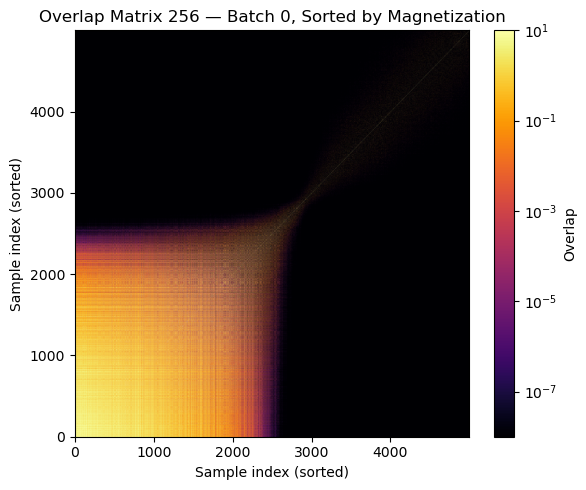

In [72]:
import matplotlib.colors as colors

# --------- Configuration ---------
overlap_dir        = "overlap_batches_testXY64.1"
samples_per_seed   = 50                      # known
batch_index        = 0                       # <-- change this to pick batch

# --------- Load files ----------
mag_labels = magnetizations
overlap_files = sorted(
    f for f in os.listdir(overlap_dir)
    if f.startswith("overlap_batch_") and f.endswith(".npy")
)

num_batches = len(overlap_files)
total_samples = mag_labels.shape[0]
samples_per_batch = total_samples // num_batches

seeds_per_batch = samples_per_batch // samples_per_seed
print(f"Inferred: {seeds_per_batch} seeds per batch, {samples_per_batch} samples per batch")

# --------- Select batch ----------
if batch_index >= num_batches:
    raise ValueError(f"batch_index {batch_index} is out of range (only {num_batches} batches)")

start_sample = batch_index * samples_per_batch
end_sample   = start_sample + samples_per_batch

mag_batch = mag_labels[start_sample:end_sample]
sort_idx = np.argsort(mag_batch)

# --------- Load and sort overlap ----------
overlap_path = os.path.join(overlap_dir, overlap_files[batch_index])
overlap = np.load(overlap_path)
overlap = overlap*10

overlap_sorted = overlap[np.ix_(sort_idx, sort_idx)]

# --------- Plot ----------
plt.figure(figsize=(6, 5))
epsilon = 1e-8
im = plt.imshow(
    overlap_sorted + epsilon,
    origin="lower",
    cmap="inferno",
    aspect="auto",
    norm=colors.LogNorm(vmin=np.min(overlap_sorted + epsilon), vmax=np.max(overlap_sorted))
)
plt.colorbar(im, label="Overlap")
plt.title(f"Overlap Matrix 256 — Batch {batch_index}, Sorted by Magnetization")
plt.xlabel("Sample index (sorted)")
plt.ylabel("Sample index (sorted)")
plt.tight_layout()
plt.show()


Processing batch 0: overlap_batches_testXY64.1/overlap_batch_0.npy
Processing batch 1: overlap_batches_testXY64.1/overlap_batch_1.npy
Processing batch 2: overlap_batches_testXY64.1/overlap_batch_2.npy
Processing batch 3: overlap_batches_testXY64.1/overlap_batch_3.npy
Processing batch 4: overlap_batches_testXY64.1/overlap_batch_4.npy


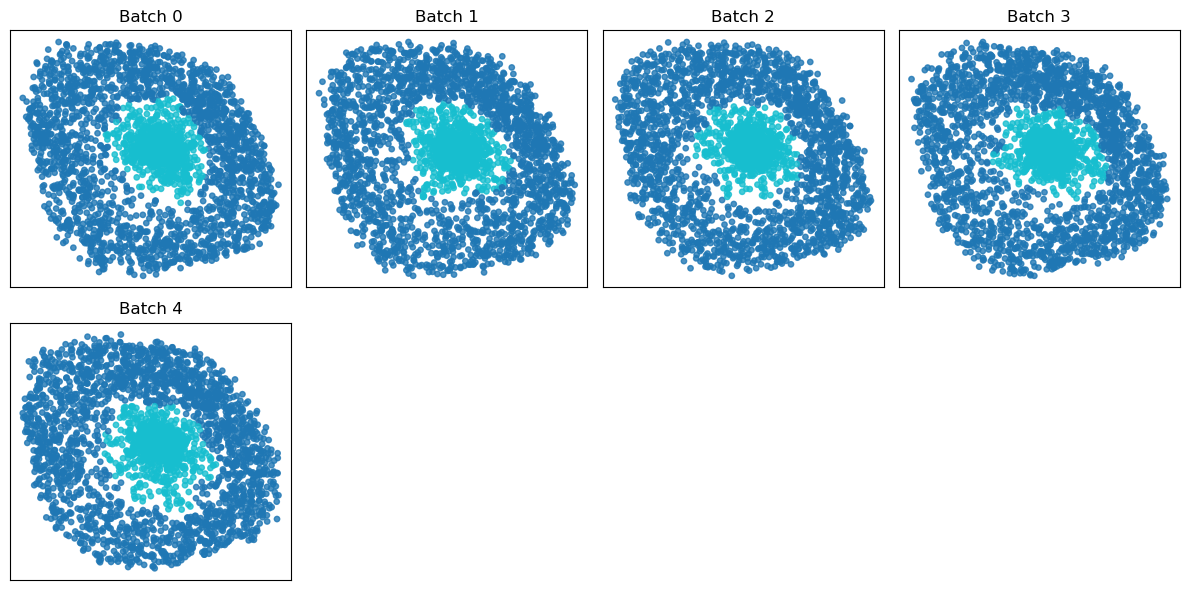

In [73]:


# ------------ Config ------------
overlap_dir = "overlap_batches_testXY64.1"
cluster_output_dir = "cluster_batches_testXY64.1"
n_clusters = 2

# Create output directories if they don't exist
os.makedirs(cluster_output_dir, exist_ok=True)

# Get all overlap files
overlap_files = (glob.glob(os.path.join(overlap_dir, "overlap_batch_*.npy")))

n_plots = len(overlap_files)
cols = 4  # number of columns in grid
rows = (n_plots + cols - 1) // cols  # ceiling division for rows

fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3), squeeze=False)

for batch_idx, overlap_file in enumerate(overlap_files):
    print(f"Processing batch {batch_idx}: {overlap_file}")
    
    overlap = np.load(overlap_file)
    overlap = overlap
    batch_size = overlap.shape[0]

    # Extract latent means for this batch
    start_idx = batch_idx * batch_size
    end_idx = start_idx + batch_size
    vae_batch = fitImgsVAE[start_idx:end_idx]

    assert vae_batch.shape[0] == batch_size, "Mismatch between overlap and latent mean batch sizes"

    # Perform Spectral Clustering
    clusters = SpectralClustering(
        n_clusters=n_clusters,
        affinity='precomputed',
        eigen_solver='arpack',
        eigen_tol=0,
        random_state=42
    ).fit_predict(overlap)

    # Save cluster assignments
    cluster_filename = os.path.join(cluster_output_dir, f"final_clusters_batch{batch_idx}.csv")
    np.savetxt(cluster_filename, clusters, delimiter=",", fmt="%d")

    # Plot on the respective subplot
    ax = axes[batch_idx // cols, batch_idx % cols]

    # If latent means are > 2D, just plot first 2 dims (no PCA)
    if vae_batch.shape[1] > 2:
        plot_data = vae_batch[:, :2]
    else:
        plot_data = vae_batch

    sc = ax.scatter(plot_data[:, 0], plot_data[:, 1], c=clusters, cmap='tab10', s=15, alpha=0.8)
    ax.set_title(f"Batch {batch_idx}")
    ax.set_xticks([])
    ax.set_yticks([])

# Remove unused subplots if any
for empty_idx in range(n_plots, rows * cols):
    fig.delaxes(axes[empty_idx // cols, empty_idx % cols])

plt.tight_layout()
plt.show()


[XY Assignment] Magnetized cluster: 0, Disordered cluster: 1
Batch 0: Magnetized = 0, Disordered = 1
[XY Assignment] Magnetized cluster: 0, Disordered cluster: 1
Batch 1: Magnetized = 0, Disordered = 1
[XY Assignment] Magnetized cluster: 0, Disordered cluster: 1
Batch 2: Magnetized = 0, Disordered = 1
[XY Assignment] Magnetized cluster: 0, Disordered cluster: 1
Batch 3: Magnetized = 0, Disordered = 1
Stopping at max_batches=4


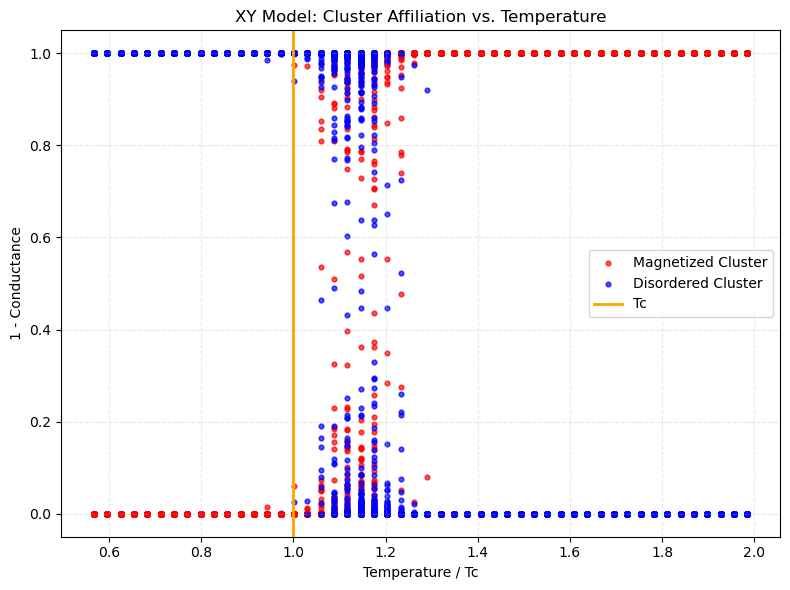

In [74]:
# ------------- Config -------------
Tc = 0.8816
overlap_dir = "overlap_batches_testXY64.1"
cluster_dir = "cluster_batches_testXY64.1"  # where your cluster CSVs are saved
temperature_labels = temp_labels
max_batches = 4

# ------------- Load Overlap Files -------------
overlap_files = sorted(glob.glob(os.path.join(overlap_dir, "overlap_batch_*.npy")))
n_batches = len(overlap_files)

# ------------- Conductance Score -------------
def compute_conductance(overlap, clusters, target_cluster, eps=1e-15):
    scores = []
    for i in range(overlap.shape[0]):
        cluster_mask = (clusters == target_cluster)
        same_cluster = overlap[i, cluster_mask]
        all_total = np.sum(overlap[i])
        score = np.sum(same_cluster) / (all_total + eps)
        scores.append(score)
    return np.array(scores)

# ------------- For XY: Identify Magnetized vs. Disordered -------------
def identify_clusters_xy(clusters, temps_batch, min_cluster_size=50):
    unique_clusters = np.unique(clusters)

    if len(unique_clusters) != 2:
        print(f"[Warning] Found {len(unique_clusters)} clusters (expected 2). Skipping batch.")
        return None, None

    for c in unique_clusters:
        count = np.sum(clusters == c)
        if count < min_cluster_size:
            print(f"[Outlier Rejection] Cluster {c} too small (size={count} < {min_cluster_size}). Skipping batch.")
            return None, None

    # Compute average temp for each cluster
    cluster_avg_temp = {c: np.mean(temps_batch[clusters == c]) for c in unique_clusters}
    
    # Lower temp → magnetized, Higher temp → disordered
    sorted_clusters = sorted(cluster_avg_temp.items(), key=lambda x: x[1])
    magnetized = sorted_clusters[0][0]
    disordered = sorted_clusters[1][0]

    print(f"[XY Assignment] Magnetized cluster: {magnetized}, Disordered cluster: {disordered}")
    return magnetized, disordered

# ------------- Loop Over Batches -------------
results = []
start_idx = 0

for batch_idx, overlap_file in enumerate(overlap_files):
    if batch_idx >= max_batches:
        print(f"Stopping at max_batches={max_batches}")
        break

    overlap = np.load(overlap_file)
    batch_size = overlap.shape[0]
    end_idx = start_idx + batch_size

    # Load cluster labels
    cluster_file = os.path.join(cluster_dir, f"final_clusters_batch{batch_idx}.csv")
    clusters = np.loadtxt(cluster_file, delimiter=",", dtype=int)

    # Get temperature labels for the batch
    temps_batch = np.array(temperature_labels[start_idx:end_idx])
    temps_scaled_batch = temps_batch / Tc

    # Identify magnetized/disordered clusters
    magnetized_cluster, disordered_cluster = identify_clusters_xy(clusters, temps_batch)
    if magnetized_cluster is None or disordered_cluster is None:
        start_idx = end_idx
        print("DID SKIP")
        continue

    # Compute conductance scores
    magnetized_score = compute_conductance(overlap, clusters, magnetized_cluster)
    disordered_score = compute_conductance(overlap, clusters, disordered_cluster)

    # Store results
    batch_result = np.column_stack([
        temps_scaled_batch,
        1 - magnetized_score,
        1 - disordered_score
    ])
    results.append(batch_result)

    print(f"Batch {batch_idx}: Magnetized = {magnetized_cluster}, Disordered = {disordered_cluster}")
    start_idx = end_idx

# ------------- Save + Plot -------------
final_result = np.vstack(results)
np.savetxt("conductance_scores_xy256.1.csv", final_result,
           delimiter=",",
           header="Temp_Scaled,1-Magnetized_Score,1-Disordered_Score",
           comments='',
           fmt="%.4f,%.6f,%.6f")

# ------------- Plot -------------
plt.figure(figsize=(8, 6))
plt.scatter(final_result[:, 0], final_result[:, 1], color='red', s=12, alpha=0.7, label='Magnetized Cluster')
plt.scatter(final_result[:, 0], final_result[:, 2], color='blue', s=12, alpha=0.7, label='Disordered Cluster')
plt.axvline(1.0, color='orange', linewidth=2, label='Tc')
plt.xlabel("Temperature / Tc")
plt.ylabel("1 - Conductance")
plt.title("XY Model: Cluster Affiliation vs. Temperature")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


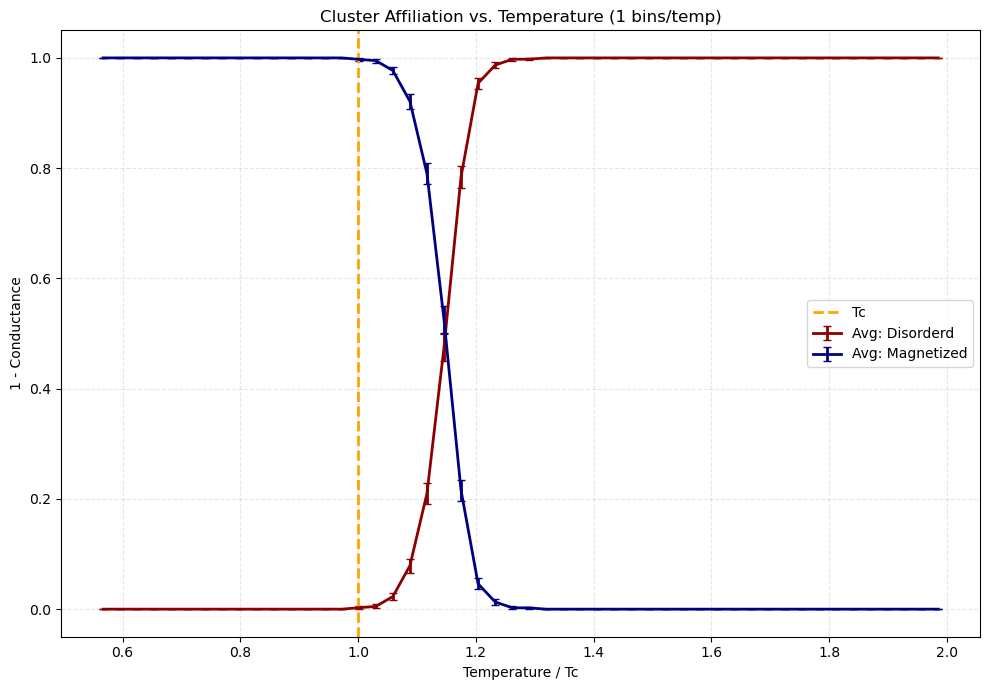

Saved to conductance_binned_testXY32.1.csv


In [75]:
# ------------------ Configuration ------------------
bins_per_temp = 1  # You can increase this
save_filename = "conductance_binned_testXY32.1.csv"

# ------------------ Input Data ---------------------
temps = final_result[:, 0]
magnetized_vals = final_result[:, 1]
disordered_vals = final_result[:, 2]

unique_temps = np.unique(temps)
binned_temp = []
binned_mag = []
binned_dis = []
binned_mag_err = []
binned_dis_err = []

# ------------------ Binning + Statistics ---------------------
for T in unique_temps:
    mask = temps == T
    indices = np.where(mask)[0]

    np.random.shuffle(indices)
    sub_bins = np.array_split(indices, bins_per_temp)

    for sub in sub_bins:
        if len(sub) > 0:
            binned_temp.append(T)
            binned_mag.append(np.mean(magnetized_vals[sub]))
            binned_dis.append(np.mean(disordered_vals[sub]))
            binned_mag_err.append(np.std(magnetized_vals[sub]) / np.sqrt(len(sub)))
            binned_dis_err.append(np.std(disordered_vals[sub]) / np.sqrt(len(sub)))

# ------------------ Convert to Arrays ---------------------
binned_temp = np.array(binned_temp)
binned_mag = np.array(binned_mag)
binned_dis = np.array(binned_dis)
binned_mag_err = np.array(binned_mag_err)
binned_dis_err = np.array(binned_dis_err)

# ------------------ Numerical Derivatives ---------------------
dmag_dT = np.gradient(binned_mag, binned_temp)
ddis_dT = np.gradient(binned_dis, binned_temp)

# ------------------ Plotting ---------------------
plt.figure(figsize=(10, 7))
plt.errorbar(binned_temp, binned_mag, yerr=binned_mag_err, color='darkred', linewidth=2, label='Avg: Disorderd', capsize=3)
plt.errorbar(binned_temp, binned_dis, yerr=binned_dis_err, color='navy', linewidth=2, label='Avg: Magnetized', capsize=3)

plt.axvline(1.0, color='orange', linewidth=2, linestyle='--', label='Tc')
plt.xlabel("Temperature / Tc")
plt.ylabel("1 - Conductance")
plt.title(f"Cluster Affiliation vs. Temperature ({bins_per_temp} bins/temp)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------ Saving Output ---------------------
output_data = np.column_stack([
    binned_temp,
    binned_mag,
    binned_mag_err,
    binned_dis,
    binned_dis_err
])
np.savetxt(
    save_filename,
    output_data,
    delimiter=",",
    header="temp_scaled,magnetized_avg,magnetized_se,disordered_avg,disordered_se",
    comments=''
)
print(f"Saved to {save_filename}")

